In [1]:
from pathlib import Path
import os
import sys

PROJECT_ROOT = Path.cwd().resolve()
if not (PROJECT_ROOT / "data").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
if not (PROJECT_ROOT / "data").exists():
    raise FileNotFoundError("Open this notebook from the NutriCore repository or its notebooks directory.")

NOTEBOOKS_DIR = PROJECT_ROOT / "notebooks"
if str(NOTEBOOKS_DIR) not in sys.path:
    sys.path.insert(0, str(NOTEBOOKS_DIR))
os.chdir(PROJECT_ROOT)

In [2]:
# Imports

import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter

pd.set_option("display.max_columns", None)

In [3]:
# Load Dataset

df = pd.read_parquet("data/raw/recipes.parquet")

print(f"Dataset Shape: {df.shape}")

df.head()

Dataset Shape: (522517, 28)


,RecipeId,Name,AuthorId,AuthorName,CookTime,PrepTime,TotalTime,DatePublished,Description,Images,RecipeCategory,Keywords,RecipeIngredientQuantities,RecipeIngredientParts,AggregatedRating,ReviewCount,Calories,FatContent,SaturatedFatContent,CholesterolContent,SodiumContent,CarbohydrateContent,FiberContent,SugarContent,ProteinContent,RecipeServings,RecipeYield,RecipeInstructions
0,38.0,Low-Fat Berry Blue Frozen Dessert,1533,Dancer,PT24H,PT45M,PT24H45M,1999-08-09 21:46:00+00:00,Make and share this Low-Fat Berry Blue Frozen ...,[https://img.sndimg.com/food/image/upload/w_55...,Frozen Desserts,"[Dessert, Low Protein, Low Cholesterol, Health...","[4, 1⁄4, 1, 1]","[blueberries, granulated sugar, vanilla yogurt...",4.5,4.0,170.9,2.5,1.3,8.0,29.8,37.1,3.6,30.2,3.2,4.0,None,"[Toss 2 cups berries with sugar., Let stand fo..."
1,39.0,Biryani,1567,elly9812,PT25M,PT4H,PT4H25M,1999-08-29 13:12:00+00:00,Make and share this Biryani recipe from Food.com.,[https://img.sndimg.com/food/image/upload/w_55...,Chicken Breast,"[Chicken Thigh & Leg, Chicken, Poultry, Meat, ...","[1, 4, 2, 2, 8, 1⁄4, 8, 1⁄2, 1, 1, 1⁄4, 1⁄4, 1...","[saffron, milk, hot green chili peppers, onion...",3.0,1.0,1110.7,58.8,16.6,372.8,368.4,84.4,9.0,20.4,63.4,6.0,None,[Soak saffron in warm milk for 5 minutes and p...
2,40.0,Best Lemonade,1566,Stephen Little,PT5M,PT30M,PT35M,1999-09-05 19:52:00+00:00,This is from one of my first Good House Keepi...,[https://img.sndimg.com/food/image/upload/w_55...,Beverages,"[Low Protein, Low Cholesterol, Healthy, Summer...","[1 1⁄2, 1, None, 1 1⁄2, None, 3⁄4]","[sugar, lemons, rind of, lemon, zest of, fresh...",4.5,10.0,311.1,0.2,0.0,0.0,1.8,81.5,0.4,77.2,0.3,4.0,None,"[Into a 1 quart Jar with tight fitting lid, pu..."
3,41.0,Carina's Tofu-Vegetable Kebabs,1586,Cyclopz,PT20M,PT24H,PT24H20M,1999-09-03 14:54:00+00:00,This dish is best prepared a day in advance to...,[https://img.sndimg.com/food/image/upload/w_55...,Soy/Tofu,"[Beans, Vegetable, Low Cholesterol, Weeknight,...","[12, 1, 2, 1, 10, 1, 3, 2, 2, 2, 1, 2, 1⁄2, 1⁄...","[extra firm tofu, eggplant, zucchini, mushroom...",4.5,2.0,536.1,24.0,3.8,0.0,1558.6,64.2,17.3,32.1,29.3,2.0,4 kebabs,"[Drain the tofu, carefully squeezing out exces..."
4,42.0,Cabbage Soup,1538,Duckie067,PT30M,PT20M,PT50M,1999-09-19 06:19:00+00:00,Make and share this Cabbage Soup recipe from F...,[https://img.sndimg.com/food/image/upload/w_55...,Vegetable,"[Low Protein, Vegan, Low Cholesterol, Healthy,...","[46, 4, 1, 2, 1]","[plain tomato juice, cabbage, onion, carrots, ...",4.5,11.0,103.6,0.4,0.1,0.0,959.3,25.1,4.8,17.7,4.3,4.0,None,"[Mix everything together and bring to a boil.,..."


In [4]:
# Dataset Overview

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 522517 entries, 0 to 522516
Data columns (total 28 columns):
 #   Column                      Non-Null Count   Dtype              
---  ------                      --------------   -----              
 0   RecipeId                    522517 non-null  float64            
 1   Name                        522517 non-null  object             
 2   AuthorId                    522517 non-null  int32              
 3   AuthorName                  522517 non-null  object             
 4   CookTime                    439972 non-null  object             
 5   PrepTime                    522517 non-null  object             
 6   TotalTime                   522517 non-null  object             
 7   DatePublished               522517 non-null  datetime64[us, UTC]
 8   Description                 522512 non-null  object             
 9   Images                      522516 non-null  object             
 10  RecipeCategory              521766 non-null 

In [5]:
df.describe()

,RecipeId,AuthorId,AggregatedRating,ReviewCount,Calories,FatContent,SaturatedFatContent,CholesterolContent,SodiumContent,CarbohydrateContent,FiberContent,SugarContent,ProteinContent,RecipeServings
count,522517.000000,5.225170e+05,269294.000000,275028.000000,522517.000000,522517.000000,522517.000000,522517.000000,5.225170e+05,522517.000000,522517.000000,522517.000000,522517.000000,339606.000000
mean,271821.436970,4.572585e+07,4.632014,5.227784,484.438580,24.614922,9.559457,86.487003,7.672639e+02,49.089092,3.843242,21.878254,17.469510,8.606191
std,155495.878422,2.929714e+08,0.641934,20.381347,1397.116649,111.485798,46.622621,301.987009,4.203621e+03,180.822062,8.603163,142.620191,40.128837,114.319809
min,38.000000,2.700000e+01,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000,1.000000
25%,137206.000000,6.947400e+04,4.500000,1.000000,174.200000,5.600000,1.500000,3.800000,1.233000e+02,12.800000,0.800000,2.500000,3.500000,4.000000
50%,271758.000000,2.389370e+05,5.000000,2.000000,317.100000,13.800000,4.700000,42.600000,3.533000e+02,28.200000,2.200000,6.400000,9.100000,6.000000
75%,406145.000000,5.658280e+05,5.000000,4.000000,529.100000,27.400000,10.800000,107.900000,7.922000e+02,51.100000,4.600000,17.900000,25.000000,8.000000
max,541383.000000,2.002886e+09,5.000000,3063.000000,612854.600000,64368.100000,26740.600000,130456.400000,1.246921e+06,108294.600000,3012.000000,90682.300000,18396.200000,32767.000000


# Recipe Data Exploration and Preprocessing

This notebook prepares the raw Food.com recipe dataset for downstream nutrition, content, and hybrid recommendation workflows.

## Feature Selection

The original Food.com dataset contains 28 columns describing recipes, authors, ratings, ingredients, nutritional information, preparation details, and media resources.

For this project, only the features required for:

* Nutritional analysis
* Dietary classification
* Recipe recommendation
* User-facing recipe summaries

will be retained.

The objective of the recommendation system is to suggest recipes that match a user's nutritional requirements and dietary preferences. Users can then access the complete recipe, ingredients, instructions, and media content through Food.com.

Removing unnecessary columns reduces memory usage, improves processing efficiency, and allows the recommendation engine to focus on the most relevant information.

The selected features can be grouped into the following categories.

### Recipe Information

* RecipeId
* Name
* Description
* RecipeCategory

These fields provide the basic information required to identify and present recipes to users.

### Recommendation Features

* Keywords
* RecipeIngredientParts

These features contain valuable information about recipe characteristics, ingredients, cuisines, and dietary properties. They will be used for dietary classification and recommendation generation.

### Nutritional Features

* Calories
* FatContent
* CarbohydrateContent
* ProteinContent
* RecipeServings

These features provide the nutritional profile of each recipe and will later be transformed into per-serving nutritional metrics. They form the foundation of nutrition-aware recommendations and serving-size optimization.


In [6]:
# Keep Relevant Columns

keep_cols = [
    "RecipeId",
    "Name",
    "Description",
    "RecipeCategory",
    "Keywords",
    "RecipeIngredientParts",
    "Calories",
    "FatContent",
    "CarbohydrateContent",
    "ProteinContent",
    "RecipeServings"
]

df = df[keep_cols]

print(df.shape)

(522517, 11)


### Dataset Shape After Feature Selection

After selecting the relevant columns, the size of the dataset is
re-evaluated.

This step confirms that only the desired features have been retained
while preserving all recipe records.

The resulting dataset will serve as the foundation for all subsequent
cleaning, feature engineering, and recommendation tasks.

## Missing Value Analysis

Before building a recommendation system, it is important to understand
the completeness of the dataset.

Missing values can affect:

- Feature engineering
- Recommendation quality
- User experience
- Model reliability

However, not every missing value should be treated equally.

Some features are essential for recommendation generation, while others
are only used for displaying recipe information.

The goal of this analysis is to identify which missing values require
action and which can safely be retained.

In [7]:
# Missing Values

missing = (
    df.isnull()
      .sum()
      .sort_values(ascending=False)
)

missing

RecipeServings           182911
RecipeCategory              751
Description                   5
RecipeId                      0
Name                          0
Keywords                      0
RecipeIngredientParts         0
Calories                      0
FatContent                    0
CarbohydrateContent           0
ProteinContent                0
dtype: int64

### Missing-Value Findings

The missing value summary reveals that `RecipeServings` contains the
largest number of missing records.

This column is particularly important because it will be used to
calculate:

- Calories per serving
- Protein per serving
- Carbohydrates per serving
- Fat per serving

Without serving information, recipes cannot be accurately compared
against user nutritional targets.

Other columns such as `Description`, and `RecipeCategory`
contain missing values as well. However, these features are not
required for nutritional calculations and therefore do not justify
removing otherwise valid recipes.

The next step focuses on quantifying the impact of missing serving
information before deciding how to handle it.

### Handling Missing Serving Information

The recommendation engine will operate on per-serving nutritional
values rather than recipe-level nutrition.

For this reason, serving size information is a critical feature.

Recipes with missing serving counts cannot be converted into
per-serving calories or macronutrients and therefore cannot be
used reliably by the recommendation engine.

Before removing these records, the proportion of affected recipes
will be calculated.

In [8]:
# Missing RecipeServings Analysis

total_recipes = len(df)

missing_servings = (
    df["RecipeServings"]
    .isnull()
    .sum()
)

missing_percentage = (
    missing_servings /
    total_recipes
) * 100

print(f"Total Recipes      : {total_recipes:,}")
print(f"Missing Servings   : {missing_servings:,}")
print(f"Percentage Missing : {missing_percentage:.2f}%")

Total Recipes      : 522,517
Missing Servings   : 182,911
Percentage Missing : 35.01%


### Removing Recipes With Missing Serving Information

Although a substantial number of recipes contain missing serving
information, these records cannot be used for personalized nutrition
recommendations.

The remaining dataset still contains hundreds of thousands of recipes,
which is more than sufficient for building a robust recommendation
system.

Therefore, recipes with missing serving information will be removed.

In [9]:
# Remove Missing Serving Information

df = df.dropna(
    subset=["RecipeServings"]
)

print(f"Remaining Recipes: {len(df):,}")

Remaining Recipes: 339,606


## Dietary Classification

A key requirement of the recommendation system is the ability to
recommend recipes according to a user's dietary preferences.

Examples include:

- Vegetarian
- Eggitarian
- Non-Vegetarian

The Food.com dataset does not provide explicit dietary labels.
Therefore, these categories must be derived from recipe titles and ingredient information.

Before creating classification rules, an exploratory analysis of recipe ingredients is performed to identify dietary indicators. The final classification combines information from both the recipe title and ingredient list to improve robustness against incomplete ingredient metadata if any.

The objective of this analysis is to:

- Understand the most common ingredients in the dataset.
- Identify ingredients associated with meat, poultry, seafood,
  and eggs.
- Develop a simple and interpretable rule-based classification
  system.

The resulting dietary category will later be used as a filtering
feature within the recommendation engine.

### Ingredient Frequency Analysis

Recipe ingredients are stored as lists within the
`RecipeIngredientParts` column.

To understand the composition of recipes within the dataset,
all ingredients will be extracted and combined into a single
collection.

This analysis will help identify the most frequently occurring
ingredients and support the creation of dietary classification
rules.

In [10]:
# Extract All Ingredients

all_ingredients = []

for ingredients in df["RecipeIngredientParts"]:

    ingredients = [
        str(i).lower().strip()
        for i in ingredients
    ]

    all_ingredients.extend(ingredients)

print(
    f"Total Ingredient Entries: "
    f"{len(all_ingredients):,}"
)

Total Ingredient Entries: 2,686,572


### Counting Ingredient Frequencies

After extracting all ingredients, the frequency of each unique
ingredient is calculated.

This allows identification of the most common ingredients used
throughout the dataset.

In [11]:
# Ingredient Frequency Counts

ingredient_counts = Counter(all_ingredients)

print(
    f"Unique Ingredients: "
    f"{len(ingredient_counts):,}"
)

Unique Ingredients: 6,646


### Most Common Ingredients

The following table displays the most frequently occurring
ingredients across all recipes.

Understanding which ingredients dominate the dataset provides
valuable context before creating dietary classification rules.

In [12]:
# Top 50 Ingredients

top_ingredients = ingredient_counts.most_common(50)

top_ingredients_df = pd.DataFrame(
    top_ingredients,
    columns=[
        "Ingredient",
        "Frequency"
    ]
)

top_ingredients_df

,Ingredient,Frequency
0,salt,126149
1,butter,83821
2,sugar,67958
3,onion,58249
4,olive oil,54517
5,water,53286
6,eggs,49466
7,garlic cloves,40874
8,milk,37643
9,flour,36185


### Ingredient Frequency Visualization

Visualizing ingredient frequencies provides a clearer view of
ingredient distribution within the dataset.

The chart below displays the most frequently occurring
ingredients across all recipes.

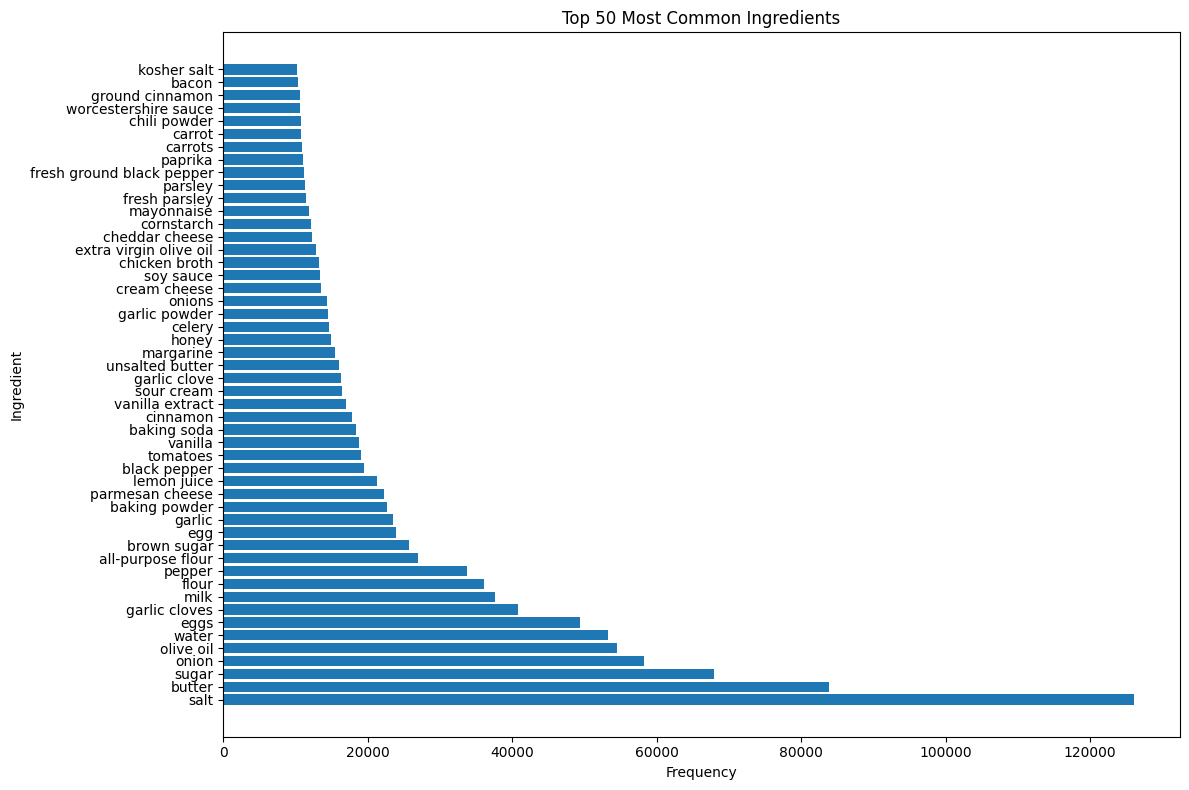

In [13]:
# Top Ingredient Visualization

top50 = ingredient_counts.most_common(50)

ingredients = [
    item[0]
    for item in top50
]

counts = [
    item[1]
    for item in top50
]

plt.figure(figsize=(12, 8))

plt.barh(
    ingredients,
    counts
)

plt.xlabel("Frequency")
plt.ylabel("Ingredient")
plt.title("Top 50 Most Common Ingredients")

plt.tight_layout()

plt.show()

### Ingredient Frequency Findings

Several interesting patterns can be observed from the ingredient
frequency distribution.

<h3>Dominance of Basic Cooking Ingredients</h3>

Ingredients such as:

- Salt
- Butter
- Sugar
- Onion
- Water
- Olive Oil

appear in a large proportion of recipes, indicating that they
serve as foundational ingredients across multiple cuisines and
recipe categories.

<h3>Presence of Protein Sources</h3>

Ingredients such as:

- Eggs
- Milk

also appear frequently throughout the dataset, suggesting that
many recipes contain significant sources of dietary protein.

<h3>Long-Tail Ingredient Distribution</h3>

The distribution demonstrates a long-tail pattern, where a small
number of ingredients occur very frequently while a large number
of ingredients appear in relatively few recipes.

This behavior is expected in recipe datasets due to the diversity
of cuisines, cooking styles, and ingredient combinations.

<h3>Implications for Dietary Classification</h3>

The ingredient analysis identifies reliable dietary keywords that are later combined with recipe titles to derive dietary categories.

In particular, ingredient keywords associated with:

- Meat and seafood
- Eggs

can be identified and used to construct a rule-based dietary
classification system.

The next step focuses on investigating these ingredient groups in
greater detail before assigning recipes to Vegetarian,
Eggitarian, and Non-Vegetarian categories.

### Identifying Dietary Indicators

To construct dietary categories, ingredient names associated
with meat, poultry, seafood, and eggs are investigated.

Rather than manually reviewing thousands of ingredients,
keyword-based searches are performed on the ingredient
vocabulary extracted from the dataset.

These findings will be used to construct the dietary classification rules. Although ingredient information forms the primary basis for classification, recipe titles are also incorporated to reduce misclassification caused by incomplete ingredient lists if any in the source dataset.

In [14]:
# Non-Vegetarian Ingredients

non_veg_terms = [
    "chicken",
    "fish",
    "beef",
    "pork",
    "mutton",
    "lamb",
    "shrimp",
    "prawn",
    "crab",
    "lobster",
    "turkey"
]

non_veg_ingredients = []

for ingredient in ingredient_counts:

    ingredient_lower = ingredient.lower()

    if any(
        term in ingredient_lower
        for term in non_veg_terms
    ):
        non_veg_ingredients.append(
            ingredient
        )

sorted(non_veg_ingredients)[:100]

['all beef wieners',
 'andouille chicken sausage',
 'andouille turkey sausage',
 'baby beef liver',
 'baby chicken',
 'baby chickens',
 'baby shrimp',
 'barbecued chicken',
 'barbecued pork',
 'barbecued pork--chinese style',
 'basic all purpose brine for meats, chicken, and turkey',
 'basic chicken stock',
 'bay shrimp',
 'beef',
 'beef barbecue',
 'beef bones with marrow',
 'beef bouillon cube',
 'beef bouillon cubes',
 'beef bouillon granules',
 'beef bouillon powder',
 'beef brisket',
 'beef broth',
 'beef burger',
 'beef burgers',
 'beef chuck',
 'beef chuck with bone',
 'beef drippings',
 'beef eye round',
 'beef fat',
 'beef flank steak',
 'beef flavored rice-a-roni',
 'beef kielbasa',
 'beef liver',
 'beef machaca',
 'beef mince',
 'beef prosciutto',
 'beef rib',
 'beef ribs',
 'beef roast',
 'beef round rump roast',
 'beef round steak',
 'beef round tip steak',
 'beef round tip steaks',
 'beef schnitzel',
 'beef shank',
 'beef short ribs with bones',
 'beef silverside',
 'beef

In [15]:
# Egg Related Ingredients

[
    ingredient
    for ingredient in ingredient_counts
    if "egg" in ingredient.lower()
][:100]

['eggs',
 'eggplant',
 'egg',
 'egg tomatoes',
 'egg substitute',
 'egg white substitute',
 'eggplants',
 'fat free egg substitute',
 'hard-boiled eggs',
 'egg beaters egg substitute',
 'raw egg yolks',
 'parmigiano-reggiano cheese',
 'japanese eggplants',
 'baby eggplant',
 'hard-boiled egg',
 'chinese eggplant',
 'ener-g egg substitute',
 'vegan egg substitute',
 'chinese eggplants',
 'japanese eggplant',
 'baby eggplants',
 'egg custard',
 'egg rotini pasta',
 'extra-large eggs',
 'globe eggplant',
 'marinated eggplant',
 'roasted eggplant packed in oil',
 'eggnog ice cream',
 'eggshells',
 'vegan egg replacer powder',
 'roasting salt blend for veggies or meats',
 'globe eggplants',
 'extra-large egg',
 'taleggio',
 'jumbo eggs',
 'pickled eggs',
 'jumbo egg',
 'flax vegan egg substitute',
 'powdered egg',
 'mixed-herb compound butter for veggies or meat',
 'how to boil eggs',
 'chicken veggie toss',
 'jumbo egg yolks',
 "ct's baked egg patties - easy &amp; lean",
 'flax eggs']

### Dietary Indicator Findings

Ingredient exploration reveals several ingredients that can be
used to distinguish dietary categories.

<h3>Non-Vegetarian Indicators</h3>

Examples include:

- Chicken
- Beef
- Pork
- Fish
- Turkey
- Shrimp
- Ham
- Bacon
- Sausage

<h3>Egg Indicators</h3>

Examples include:

- Egg
- Eggs
- Hard-boiled egg

During exploratory analysis, potential classification conflicts
were also identified.

For example:

- Eggplant contains the substring "egg" but is vegetarian.
- Vegetarian meat alternatives may contain words such as
  "sausage", "bacon", or "ham" despite being vegetarian.

To address these cases, a set of vegetarian exceptions will be
used alongside dietary keywords when constructing the
classification rules.

### Dietary Classification Rules

The Food.com dataset does not provide explicit dietary labels.

To support recipe filtering and personalized recommendations,
recipes will be classified into three dietary categories:

- Vegetarian
- Eggitarian
- Non-Vegetarian

The classification process is rule-based and uses both the recipe title and ingredient list. Combining these two sources helps identify recipes whose ingredient metadata may be incomplete while maintaining an interpretable and efficient classification approach.

Ingredient frequency analysis was used to identify commonly
occurring meat, poultry, seafood, and egg-related ingredients.

To improve classification quality, known vegetarian exceptions such as eggplant and vegetarian meat substitutes are excluded before keyword matching is performed across the combined recipe title and ingredient text.

In [16]:
# Dietary Classification Keywords

NON_VEG_KEYWORDS = {
    # Poultry
    "chicken", "turkey", "duck", "goose", "quail",

    # Beef
    "beef", "steak", "meat", "meatloaf", "meatball", "meatballs",
    "burger", "burgers", "hamburger", "joe", "veal",
    "eye of round", "top round", "bottom round",
    "ground beef", "beef brisket", "beef chuck",
    "sirloin", "ribeye", "tenderloin", "flank steak","braciola","braciole",

    # Pork
    "pork", "ham", "bacon", "sausage", "sausages", "prosciutto",
    "pancetta", "pepperoni", "salami", "kielbasa", "chorizo",
    "rib", "ribs", "ground pork", "pork loin", "pork shoulder",

    # Lamb / Goat
    "lamb", "mutton", "goat",

    # Seafood
    "fish", "seafood", "seaside", "salmon", "tuna", "cod",
    "halibut", "catfish", "trout", "haddock", "snapper",
    "tilapia", "mahi", "pomfret", "anchovy", "anchovies",
    "sardine", "sardines", "shrimp", "prawn", "prawns",
    "crab", "crabmeat", "lobster", "clam", "clams",
    "mussel", "mussels", "oyster", "oysters",
    "scallop", "scallops", "squid", "calamari", "octopus"
}

EGG_KEYWORDS = {
    "egg", "eggs", "omelet", "omelette", "frittata", "quiche"
}

VEG_EXCEPTIONS = {
    # Egg-based exceptions
    "eggplant", "eggplants", "egg substitute",
    "egg beaters egg substitute",

    # Vegetarian / Vegan meat substitutes
    "vegetarian bacon", "vegan bacon", "tempeh bacon",
    "vegetarian canadian bacon", "vegetarian bacon bits",

    "vegetarian sausage", "vegetarian sausage links",
    "vegetarian sausage patties",
    "vegetarian breakfast sausage",
    "vegetarian breakfast sausage patties",
    "vegetarian italian sausages",
    "vegan sausage links",

    "vegetarian pepperoni", "vegan pepperoni",
    "vegetarian salami",
    "vegetarian kielbasa",
    "vegetarian oyster sauce",
    "vegetarian ham",

    "vegetarian hamburger patty",
    "vegetarian hamburger patties",
    "vegetarian burger", "vegetarian burgers",
    "veggie burger", "veggie burgers",
    "vegan burger", "vegan burgers",

    "vegetarian meatballs", "vegan meatballs",
    "vegetarian meatloaf", "vegan meatloaf",
    "vegetarian ribs", "vegan ribs",

    "vegetarian chicken", "vegan chicken",
    "vegetarian beef", "vegan beef",
    "vegetarian pork", "vegan pork",

    "vegetarian ground beef", "vegan ground beef",
    "vegetarian pork loin", "vegan pork loin",
    "vegetarian pork shoulder", "vegan pork shoulder",
    "vegetarian beef brisket", "vegan beef brisket",
    "vegetarian beef chuck", "vegan beef chuck",
    "vegetarian eye of round", "vegan eye of round",
    "vegetarian sirloin", "vegan sirloin",
    "vegetarian ribeye", "vegan ribeye",
    "vegetarian flank steak", "vegan flank steak",

    "mock chicken", "mock duck", "mock meat",
    "seitan", "tempeh", "tvp"
}

### Creating the Classification Function

A custom rule-based function is used to inspect both the recipe title and ingredient list before assigning a dietary category.

The classification process follows three steps:

1. Combine the recipe title and ingredient list into a single searchable text.
2. Remove known vegetarian exceptions.
3. Search for non-vegetarian ingredients.
4. Search for egg-related ingredients.

Recipes containing meat, poultry, or seafood keywords are classified as Non-Vegetarian.

Recipes containing egg-related keywords but no non-vegetarian keywords are classified as Eggitarian.

All remaining recipes are classified as Vegetarian.

Incorporating recipe titles improves robustness by reducing misclassification caused by incomplete ingredient metadata if any in the source dataset.

In [17]:
# Diet Classification Function

def classify_diet(name, ingredients):

    ingredients = [
        str(ingredient).lower().strip()
        for ingredient in ingredients
    ]

    filtered_ingredients = [
        ingredient
        for ingredient in ingredients
        if ingredient not in VEG_EXCEPTIONS
    ]

    recipe_text = (
        str(name).lower().strip()
        + " "
        + " ".join(filtered_ingredients)
    )

    # Non-Vegetarian Check
    if any(
        keyword in recipe_text
        for keyword in NON_VEG_KEYWORDS
    ):
        return "Non-Vegetarian"

    # Eggitarian Check
    if any(
        keyword in recipe_text
        for keyword in EGG_KEYWORDS
    ):
        return "Eggitarian"

    return "Vegetarian"

### Generating the Dietary Classification Feature

The classification function is applied to every recipe using both the recipe title and ingredient list to generate a new feature called `DietType`.

This feature will later be used to filter recommendations
according to user dietary preferences.

In [18]:
# Create DietType Feature

df["DietType"] = df.apply(
    lambda row: classify_diet(
        row["Name"],
        row["RecipeIngredientParts"]
    ),
    axis=1
)

### Distribution of Dietary Categories

After generating the dietary classification feature, the
distribution of recipes across Vegetarian, Eggitarian, and
Non-Vegetarian categories is examined.

This provides a high-level validation of the rule-based
classification process.

In [19]:
# Diet Type Distribution

df["DietType"].value_counts()

DietType
Non-Vegetarian    148812
Vegetarian        134776
Eggitarian         56018
Name: count, dtype: int64

### Manual Validation

Rule-based classification systems should be manually inspected
before being used in downstream applications.

Random samples are reviewed to verify that:

- Recipe titles and ingredient lists are consistent with the assigned dietary category.
- Vegetarian recipes do not contain meat or seafood
  ingredients.
- Eggitarian recipes contain egg-related ingredients but no
  meat or seafood ingredients.
- Non-Vegetarian recipes contain meat, poultry, or seafood
  ingredients.

This validation step helps identify edge cases and improve the
quality of the dietary classification rules.

In [20]:
# Manual Validation Sample

df.sample(
    20,
    random_state=42
)[
    [
        "Name",
        "DietType",
        "RecipeIngredientParts"
    ]
]

,Name,DietType,RecipeIngredientParts
139385,Turkey Divan for Two,Non-Vegetarian,"[broccoli, butter, all-purpose flour, milk, dr..."
197819,Six Week Muffins,Eggitarian,"[margarine, sugar, eggs, buttermilk, flour, ba..."
413360,Eggplant Stuffed With Ricotta and Ham,Non-Vegetarian,"[eggplants, olive oil, olive oil, shallot, gro..."
366178,Firecracker Wraps,Non-Vegetarian,"[sour cream, mayonnaise, green onion, salt, pe..."
241396,T-Dawg Turkey Chili,Non-Vegetarian,"[garbanzo beans, pinto beans, black beans, kid..."
501946,Farro Salad With Vegetables,Vegetarian,"[fresh green beans, grape tomatoes, green onio..."
445612,Herring Salsa,Vegetarian,"[herring in wine sauce, Spanish onion, lemon, ..."
311172,Gingerbread Pancakes,Eggitarian,"[all-purpose flour, baking powder, baking soda..."
509325,Edible Sprinkle Bowls,Vegetarian,[]
115254,Peach Royale,Vegetarian,"[nonfat milk, sugar, vanilla]"


## Feature Engineering

The nutritional information provided in the Food.com dataset
represents the entire recipe rather than a single serving.

However, users consume individual servings instead of complete
recipes.

For example:

- A recipe may contain 1200 calories in total.
- If the recipe serves 4 people, each serving contains
  approximately 300 calories.

Using recipe-level nutrition would make comparisons between
recipes misleading because recipes vary significantly in serving
size.

To standardize nutritional information across all recipes,
per-serving nutritional features will be created.

These engineered features will later be used to match recipes
against user calorie and macronutrient targets.

### Per-Serving Nutritional Features

The following features will be generated:

### CaloriesPerServing

Represents the calories contained in a single serving of the
recipe.

### ProteinPerServing

Represents the protein content contained in a single serving.

### CarbsPerServing

Represents the carbohydrate content contained in a single
serving.

### FatPerServing

Represents the fat content contained in a single serving.

These features provide a standardized nutritional representation
for every recipe and form the foundation of the recommendation
system.

In [21]:
# Per-Serving Nutritional Features

df["CaloriesPerServing"] = (
    df["Calories"] /
    df["RecipeServings"]
)

df["ProteinPerServing"] = (
    df["ProteinContent"] /
    df["RecipeServings"]
)

df["CarbsPerServing"] = (
    df["CarbohydrateContent"] /
    df["RecipeServings"]
)

df["FatPerServing"] = (
    df["FatContent"] /
    df["RecipeServings"]
)

### Feature Verification

After feature creation, a sample of recipes is inspected to
verify that the calculations have been performed correctly.

This validation step helps ensure that the newly created
features contain realistic values before they are used by the
recommendation engine.

In [22]:
# Verify Engineered Features

df[
    [
        "Name",
        "RecipeServings",
        "CaloriesPerServing",
        "ProteinPerServing",
        "CarbsPerServing",
        "FatPerServing"
    ]
].head()

,Name,RecipeServings,CaloriesPerServing,ProteinPerServing,CarbsPerServing,FatPerServing
0,Low-Fat Berry Blue Frozen Dessert,4.0,42.725000,0.800000,9.275000,0.625
1,Biryani,6.0,185.116667,10.566667,14.066667,9.800
2,Best Lemonade,4.0,77.775000,0.075000,20.375000,0.050
3,Carina's Tofu-Vegetable Kebabs,2.0,268.050000,14.650000,32.100000,12.000
4,Cabbage Soup,4.0,25.900000,1.075000,6.275000,0.100


### Feature Distribution

Before building the recommendation engine, it is important to
understand the distribution of the newly created nutritional
features.

This analysis helps identify:

- Extreme values
- Potential outliers
- Unrealistic nutritional values
- Data quality issues

The results will guide any additional preprocessing steps
required before recommendation generation.

In [23]:
# Nutrition Statistics

nutrition_cols = [
    "CaloriesPerServing",
    "ProteinPerServing",
    "CarbsPerServing",
    "FatPerServing"
]

df[nutrition_cols].describe(
    percentiles=[
        0.90,
        0.95,
        0.99
    ]
)

,CaloriesPerServing,ProteinPerServing,CarbsPerServing,FatPerServing
count,339606.000000,339606.000000,339606.000000,339606.000000
mean,103.928356,4.250702,10.115077,5.067292
std,807.946963,12.009523,189.889381,18.992103
min,0.000000,0.000000,0.000000,0.000000
50%,51.233333,1.600000,4.050000,2.050000
90%,188.975000,9.800000,17.300000,9.700000
95%,287.600000,14.350000,27.300000,15.375000
99%,834.695000,33.900000,84.497500,47.200000
max,434360.200000,1980.800000,108294.600000,2128.500000


## Outlier Investigation

The statistical summary reveals a substantial gap between the
99th percentile and the maximum values for several nutritional
features.

For example:

- 99% of recipes contain fewer than 835 calories per serving.
- The maximum observed value exceeds 434,000 calories per serving.

Similarly large differences are observed for protein,
carbohydrates, and fat.

These observations suggest the presence of extreme outliers that
may result from:

- Data entry errors
- Incorrect serving information
- Unusual recipes
- Data processing issues

Before applying any cleaning strategy, the recipes responsible
for these extreme values will be examined.

In [24]:
# Highest Calories Per Serving

df.sort_values(
    by="CaloriesPerServing",
    ascending=False
)[
    [
        "Name",
        "Calories",
        "RecipeServings",
        "CaloriesPerServing"
    ]
].head(20)

,Name,Calories,RecipeServings,CaloriesPerServing
185088,Tennessee Moonshine,434360.2,1.0,434360.20
2741,Hot Chocolate Dry Mix,25248.7,1.0,25248.70
2304,Green Olives,19657.5,1.0,19657.50
387910,Rendering Beef Fat for Suet Cakes and Cones (B...,17823.9,1.0,17823.90
517196,Granny Jones' Secret Salty Sweet Biscuit Recipe,17551.6,1.0,17551.60
501834,Elaine's Caramel Snack Mix,16145.5,1.0,16145.50
1759,My Sin (Dessert),14945.6,1.0,14945.60
520943,Elisenlebkuchen,13967.3,1.0,13967.30
513975,Fried Chicken Oysters and Squid Ink Linguini,13671.0,1.0,13671.00
434356,Cinnamon &amp; Sugar Pecans,13596.6,1.0,13596.60


### Protein Outliers

Protein content is one of the most important nutritional
features for the recommendation system.

Recipes with extremely high protein values will also be
inspected to determine whether the values are realistic or
caused by abnormal serving information.

In [25]:
# Highest Protein Per Serving

df.sort_values(
    by="ProteinPerServing",
    ascending=False
)[
    [
        "Name",
        "ProteinContent",
        "RecipeServings",
        "ProteinPerServing"
    ]
].head(20)

,Name,ProteinContent,RecipeServings,ProteinPerServing
185088,Tennessee Moonshine,1980.8,1.0,1980.800
187118,Pork Sandwich,1420.8,1.0,1420.800
39053,Devonshire Sandwich Pittsburgh original!!,1319.2,1.0,1319.200
491754,Turkey Brine With Wine - Martha Stewart,1227.1,1.0,1227.100
2741,Hot Chocolate Dry Mix,1122.6,1.0,1122.600
256665,Maple Apple Roasted Turkey,1112.9,1.0,1112.900
508837,THE HOUSE OF PERONI AND FRANCESCO MAZZEI PRESE...,4437.2,4.0,1109.300
289652,Turkey Brine,1078.7,1.0,1078.700
242244,Redeye Ribs With Cafe Au Lait Barbecue Sauce,3278.3,4.0,819.575
55534,Scott Hibb's Amazing Whiskey Grilled Baby Back...,3270.3,4.0,817.575


### Extreme Nutritional Values

The previous inspection revealed recipes with unrealistically
high nutritional values.

To understand the scale of the issue, the number of recipes
exceeding reasonable nutritional thresholds will be examined.

The following thresholds are used as initial indicators of
potential outliers:

- Calories per serving > 2000 kcal
- Protein per serving > 100 g
- Carbohydrates per serving > 200 g
- Fat per serving > 100 g

These thresholds are not used for removal at this stage. They
are intended only to quantify the extent of extreme nutritional
values within the dataset.

In [26]:
# Extreme Nutritional Values

print(
    "Recipes with CaloriesPerServing > 2000:",
    (df["CaloriesPerServing"] > 2000).sum()
)

print(
    "Recipes with ProteinPerServing > 100:",
    (df["ProteinPerServing"] > 100).sum()
)

print(
    "Recipes with CarbsPerServing > 200:",
    (df["CarbsPerServing"] > 200).sum()
)

print(
    "Recipes with FatPerServing > 100:",
    (df["FatPerServing"] > 100).sum()
)

Recipes with CaloriesPerServing > 2000: 1373
Recipes with ProteinPerServing > 100: 496
Recipes with CarbsPerServing > 200: 1514
Recipes with FatPerServing > 100: 1416


### Outlier Removal Impact

Extreme nutritional values appear to affect only a small portion
of the dataset.

Before removing any records, the total number of recipes that
would be excluded under the selected nutritional thresholds is
calculated.

This provides a clear understanding of the impact of the
cleaning process on the overall dataset size.

In [27]:
# Recipes Flagged As Nutritional Outliers

outlier_mask = (
    (df["CaloriesPerServing"] > 2000)
    |
    (df["ProteinPerServing"] > 100)
    |
    (df["CarbsPerServing"] > 200)
    |
    (df["FatPerServing"] > 100)
)

print(
    f"Outlier Recipes: "
    f"{outlier_mask.sum():,}"
)

print(
    f"Percentage Removed: "
    f"{(outlier_mask.mean() * 100):.2f}%"
)

Outlier Recipes: 2,290
Percentage Removed: 0.67%


### Outlier Removal

The previous analysis identified a small number of recipes with
extreme nutritional values.

Examples included recipes reporting:

- Thousands of grams of protein per serving
- Hundreds of thousands of calories per serving

Such values are unlikely to represent realistic meal portions
and may negatively affect recommendation quality.

The impact analysis showed that only 0.67% of recipes were
flagged as potential nutritional outliers.

Given the small proportion of affected records and the
unrealistic nature of the values, these recipes will be removed
from the dataset.

The following thresholds are applied:

- Calories per serving ≤ 2000 kcal
- Protein per serving ≤ 100 g
- Carbohydrates per serving ≤ 200 g
- Fat per serving ≤ 100 g

In [28]:
# Remove Nutritional Outliers

df = df[
    (df["CaloriesPerServing"] <= 2000)
    &
    (df["ProteinPerServing"] <= 100)
    &
    (df["CarbsPerServing"] <= 200)
    &
    (df["FatPerServing"] <= 100)
]

print(
    f"Remaining Recipes: "
    f"{len(df):,}"
)

Remaining Recipes: 337,316


### Cleaned Dataset Verification

After removing nutritional outliers, summary statistics are
recomputed to verify that the remaining recipes fall within
reasonable nutritional ranges.

This final validation step ensures that the dataset is suitable
for building the recommendation engine.

In [29]:
# Statistics After Cleaning

df[
    [
        "CaloriesPerServing",
        "ProteinPerServing",
        "CarbsPerServing",
        "FatPerServing"
    ]
].describe(
    percentiles=[
        0.90,
        0.95,
        0.99
    ]
)

,CaloriesPerServing,ProteinPerServing,CarbsPerServing,FatPerServing
count,337316.000000,337316.000000,337316.000000,337316.000000
mean,83.379475,3.791189,7.592038,4.074040
std,112.523922,5.879828,12.532862,6.877596
min,0.000000,0.000000,0.000000,0.000000
50%,50.775000,1.575000,4.003333,2.025000
90%,182.300000,9.550000,16.700000,9.350000
95%,266.900000,13.600000,25.466667,14.400000
99%,574.200000,27.900000,61.550000,34.200000
max,1967.400000,99.200000,200.000000,99.933333


## Data Quality Cleaning

Additional data quality checks were performed to identify recipes that could negatively affect nutrition-based recommendations.

Recipes with missing nutritional profiles were identified by checking whether all major nutritional fields were equal to zero.

Such recipes do not provide meaningful nutritional information and cannot be used reliably for calorie-aware or macro-aware recommendation. Therefore, they are removed from the dataset.




In [30]:
# Remove Invalid Nutrition Profiles

invalid_nutrition_mask = (
    (df["Calories"] <= 0)
    |
    (
        (df["ProteinContent"] <= 0)
        &
        (df["CarbohydrateContent"] <= 0)
        &
        (df["FatContent"] <= 0)
    )
)

print(
    f"Recipes removed due to invalid nutrition: "
    f"{invalid_nutrition_mask.sum():,}"
)

df = df.loc[
    ~invalid_nutrition_mask
].copy()

Recipes removed due to invalid nutrition: 2,765


### Serving Size Filtering

The Food.com dataset contains recipes ranging from single-serving meals to large-batch preparations intended for parties, catering events, commercial production, and bulk food preparation.

Since this project focuses on personalized nutrition and diet recommendation, recipes with extremely large serving counts are unlikely to be suitable for individual meal planning.

An inspection of the serving-size distribution revealed that recipes with very large serving counts frequently correspond to cookies, desserts, beverages, condiments, spreads, and other bulk-preparation recipes rather than complete meals.

To maintain a recommendation pool that better reflects realistic household meal preparation, recipes with more than 20 servings are removed.

This threshold preserves the vast majority of normal household recipes while reducing the number of large-batch and catering-oriented recipes that are not relevant to personalized diet recommendations.


In [31]:
# Remove Extremely Large Serving Recipes

MAX_SERVINGS = 20

recipes_removed = (
    df["RecipeServings"] > MAX_SERVINGS
).sum()

print(
    f"Recipes removed due to serving size > {MAX_SERVINGS}: "
    f"{recipes_removed:,}"
)

df = df.loc[
    df["RecipeServings"] <= MAX_SERVINGS
].copy()

print(
    f"Remaining recipes: {len(df):,}"
)

Recipes removed due to serving size > 20: 19,337
Remaining recipes: 315,214


In [32]:
print(
    f"Percentage removed: "
    f"{recipes_removed / (len(df) + recipes_removed) * 100:.2f}%"
)

Percentage removed: 5.78%


## Nutrition Consistency Validation

The dataset provides both reported calorie values and macronutrient
information (protein, carbohydrates, and fat).

According to standard nutritional calculations:

- Protein contributes approximately 4 kcal per gram
- Carbohydrates contribute approximately 4 kcal per gram
- Fat contributes approximately 9 kcal per gram

Using these conversion factors, calories can be estimated from the
macronutrient composition of each recipe.

A validation check is performed to compare reported calories against
calories estimated from macronutrients.

The purpose of this analysis is to evaluate the consistency and
reliability of the nutritional information contained in the dataset.

In [33]:
## Nutrition Consistency Validation

calculated_calories = (
    df["ProteinContent"] * 4
    + df["CarbohydrateContent"] * 4
    + df["FatContent"] * 9
)

difference_pct = (
    abs(
        df["Calories"]
        - calculated_calories
    )
    / calculated_calories
) * 100

difference_pct.describe(
    percentiles=[
        0.90,
        0.95,
        0.99
    ]
)

count    315214.000000
mean         19.158176
std         585.460965
min           0.000000
50%           2.137190
90%           8.179420
95%          12.373206
99%         150.924776
max      115550.000000
dtype: float64

### Nutrition Consistency Filtering

Analysis of the calorie-difference distribution showed that
approximately 95% of recipes fall within a 13.4% difference between
reported calories and calories estimated from macronutrients.

Based on this observation, a tolerance threshold of ±15% was selected.

Recipes whose calorie values differ by more than 15% from the
macronutrient-derived estimate are considered nutritionally
inconsistent and are removed from the dataset.

This filtering step improves the reliability of nutritional
information used by the recommendation engine while retaining the
vast majority of recipes in the dataset.

In [34]:
# Remove Nutritionally Inconsistent Recipes

calculated_calories = (
    4 * df["ProteinContent"]
    + 4 * df["CarbohydrateContent"]
    + 9 * df["FatContent"]
)

difference_pct = (
    abs(df["Calories"] - calculated_calories)
    / calculated_calories
) * 100

TOLERANCE = 15

original_count = len(df)

df = df.loc[
    difference_pct <= TOLERANCE
].copy()

removed_count = original_count - len(df)

print(f"Recipes removed: {removed_count:,}")
print(f"Remaining recipes: {len(df):,}")
print(
    f"Percentage removed: "
    f"{(removed_count / original_count) * 100:.2f}%"
)

Recipes removed: 12,249
Remaining recipes: 302,965
Percentage removed: 3.89%


## Exporting the Processed Dataset

The dataset has now been cleaned and transformed for use in the
recipe recommendation system.

The preprocessing pipeline included:

- Selection of relevant recipe attributes
- Removal of recipes with missing serving information
- Exploratory analysis of recipe ingredients
- Creation of dietary classifications
- Generation of per-serving nutritional features
- Identification and removal of extreme nutritional outliers

The processed dataset will be exported and used as the input for
the recommendation engine developed in the next stage of the
project.

In [35]:
# Save Processed Dataset

df.to_parquet(
    "data/processed/recipes_processed.parquet",
    index=False
)

print(
    "Processed dataset saved successfully."
)

Processed dataset saved successfully.


### Preview of the Final Dataset

The first few rows of the processed dataset are displayed below
to verify that all preprocessing and feature engineering steps
have been applied successfully.

This dataset will serve as the input for the recommendation
engine developed in the next stage of the project.

In [36]:
# Final Dataset Preview

df.head()

,RecipeId,Name,Description,RecipeCategory,Keywords,RecipeIngredientParts,Calories,FatContent,CarbohydrateContent,ProteinContent,RecipeServings,DietType,CaloriesPerServing,ProteinPerServing,CarbsPerServing,FatPerServing
0,38.0,Low-Fat Berry Blue Frozen Dessert,Make and share this Low-Fat Berry Blue Frozen ...,Frozen Desserts,"[Dessert, Low Protein, Low Cholesterol, Health...","[blueberries, granulated sugar, vanilla yogurt...",170.9,2.5,37.1,3.2,4.0,Vegetarian,42.725000,0.800000,9.275000,0.625
1,39.0,Biryani,Make and share this Biryani recipe from Food.com.,Chicken Breast,"[Chicken Thigh & Leg, Chicken, Poultry, Meat, ...","[saffron, milk, hot green chili peppers, onion...",1110.7,58.8,84.4,63.4,6.0,Non-Vegetarian,185.116667,10.566667,14.066667,9.800
2,40.0,Best Lemonade,This is from one of my first Good House Keepi...,Beverages,"[Low Protein, Low Cholesterol, Healthy, Summer...","[sugar, lemons, rind of, lemon, zest of, fresh...",311.1,0.2,81.5,0.3,4.0,Vegetarian,77.775000,0.075000,20.375000,0.050
3,41.0,Carina's Tofu-Vegetable Kebabs,This dish is best prepared a day in advance to...,Soy/Tofu,"[Beans, Vegetable, Low Cholesterol, Weeknight,...","[extra firm tofu, eggplant, zucchini, mushroom...",536.1,24.0,64.2,29.3,2.0,Vegetarian,268.050000,14.650000,32.100000,12.000
4,42.0,Cabbage Soup,Make and share this Cabbage Soup recipe from F...,Vegetable,"[Low Protein, Vegan, Low Cholesterol, Healthy,...","[plain tomato juice, cabbage, onion, carrots, ...",103.6,0.4,25.1,4.3,4.0,Vegetarian,25.900000,1.075000,6.275000,0.100


In [37]:
df.shape

(302965, 16)

## Final Summary

The Food.com dataset was cleaned and prepared for use in a personalized nutrition and recipe recommendation system.

The preprocessing pipeline included:

* Selection of relevant recipe and nutritional attributes
* Removal of recipes with missing serving information
* Exploratory analysis of recipe ingredients
* Creation of Vegetarian, Eggitarian, and Non-Vegetarian dietary classifications
* Generation of per-serving nutritional features
* Investigation of nutritional outliers
* Removal of recipes with missing nutritional profiles
* Nutrition consistency validation using macronutrient-derived calorie estimates
* Removal of nutritionally inconsistent recipes
* Filtering of recipes with extremely large serving sizes

The final processed dataset contains:

* 302,965 recipes
* 16 features

This processed dataset provides reliable nutritional information, dietary classifications, and serving-level nutrition metrics that will be used in the next stages of the project, including nutrition target calculation, recipe recommendation, and personalized meal planning.
